# Maximum Likelihood Estimation (MLE): Complete Guide

## 1. Introduction and Overview

Maximum Likelihood Estimation (MLE) is the foundational optimization framework for parametric statistical inference. It operates on an inverse probability principle: rather than calculating the probability of data given fixed parameters, MLE identifies the parameters that maximize the probability of the fixed, observed data.

This notebook provides a complete, hands-on guide to MLE, bridging the theoretical foundations with production-grade computational implementations. We will cover analytical derivations, numerical optimization, asymptotic properties, and real-world engineering examples.

In [1]:
# Setup and Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
import warnings

# Set display options and style
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

# Set random seed for reproducibility
np.random.seed(42)
print('Libraries imported and random seed set to 42.')

Libraries imported and random seed set to 42.


## 2. Core Concept 1: Probability vs. Likelihood

The distinction between probability and likelihood is structural:

- Probability Distribution $$P(X | theta)$$: The parameters 'theta' are fixed, and the data 'X' is the variable. The probabilities sum to 1 over the sample space. It is a forward projection.
- Likelihood Function $$L(theta | X)$$: The data 'X' is fixed (observed), and the parameters 'theta' are the variables. It represents the plausibility of different parameters having generated the data. It does not integrate to 1.

Let's create some synthetic data to demonstrate this. Imagine we are testing a mystery coin. We flip it 20 times and observe 15 heads.

In [2]:
# Data Creation: The Mystery Coin
n_trials = 20
true_p = 0.75  # We know this, but the model won't!

# Generate synthetic coin flips (1 = Heads, 0 = Tails)
coin_flips = np.random.binomial(n=1, p=true_p, size=n_trials)

successes = np.sum(coin_flips)
failures = n_trials - successes

print(f'Experiment Results:')
print(f'Total Trials (n): {n_trials}')
print(f'Observed Heads (k): {successes}')
print(f'Observed Tails: {failures}')
print(f'Raw Data Array: {coin_flips}')

Experiment Results:
Total Trials (n): 20
Observed Heads (k): 16
Observed Tails: 4
Raw Data Array: [1 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1]


### Visualizing the Likelihood Function

The Binomial Probability Mass Function is:
$$f(k | p) = (n choose k) * p^k * (1-p)^(n-k)$$

Ignoring the constant (n choose k), the Likelihood function is:
$$L(p | k, n) = p^k * (1-p)^(n-k)$$

Let's compute and plot this likelihood across all possible values of p (from 0.01 to 0.99).

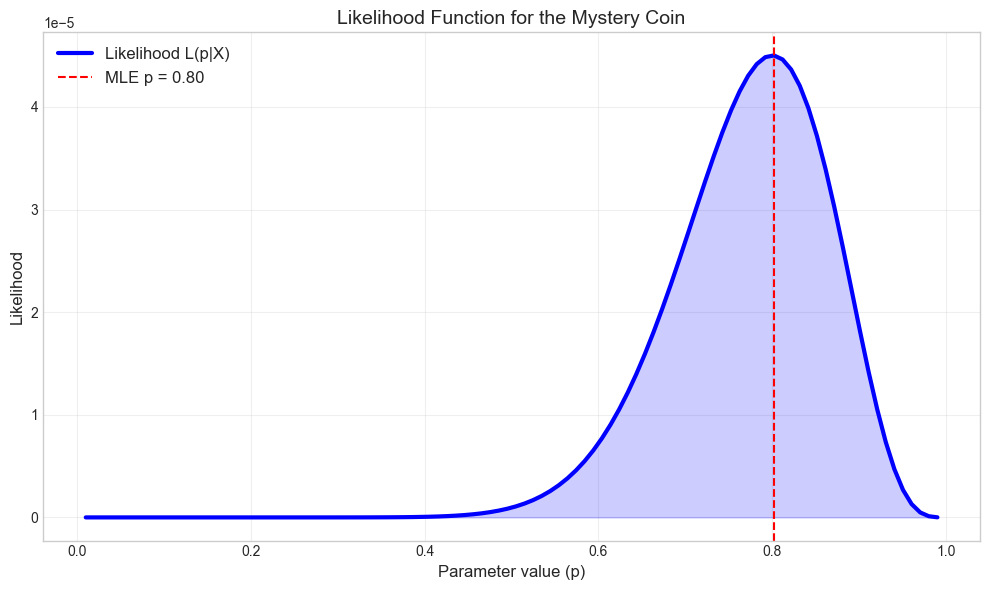

The Maximum Likelihood Estimate for p is approximately 0.80
Notice this matches the empirical mean: 0.80


In [3]:
# Define the parameter space (possible values for p)
p_values = np.linspace(0.01, 0.99, 100)

# Compute raw likelihood for each p given our FIXED data
# L(p) = p^k * (1-p)^(n-k)
likelihoods = (p_values ** successes) * ((1 - p_values) ** failures)

# Find the parameter p that maximizes the likelihood
max_idx = np.argmax(likelihoods)
mle_p = p_values[max_idx]

plt.figure(figsize=(10, 6))
plt.plot(p_values, likelihoods, lw=3, color='blue', label='Likelihood L(p|X)')
plt.axvline(mle_p, color='red', linestyle='--', label=f'MLE p = {mle_p:.2f}')
plt.fill_between(p_values, likelihoods, alpha=0.2, color='blue')

plt.title('Likelihood Function for the Mystery Coin', fontsize=14)
plt.xlabel('Parameter value (p)', fontsize=12)
plt.ylabel('Likelihood', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'The Maximum Likelihood Estimate for p is approximately {mle_p:.2f}')
print(f'Notice this matches the empirical mean: {successes/n_trials:.2f}')

## 3. The Log-Likelihood Transformation

In production systems, computing the raw likelihood L(theta|X) fails due to numerical underflow. Multiplying hundreds of small probabilities quickly results in exactly 0.0 in computer memory.

To solve this, we take the natural logarithm:
l(theta|X) = ln(L(theta|X)) = Sum_{i=1 to n} ln(f(x_i|theta))

Because log is a monotonically increasing function, the parameter that maximizes the Log-Likelihood is the exact same parameter that maximizes the raw Likelihood.

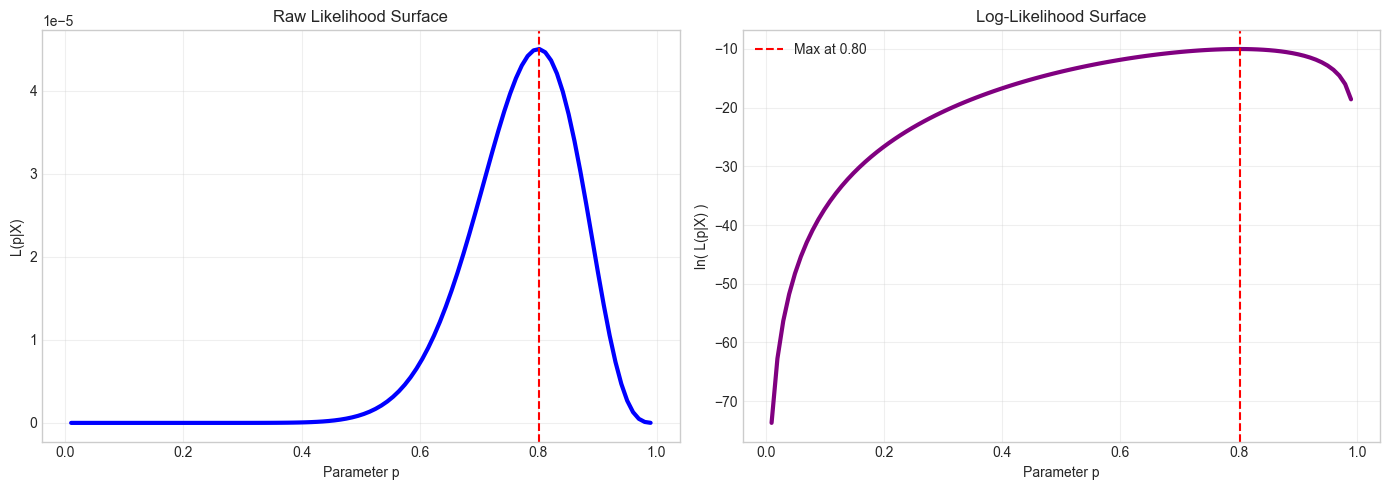

Notice how the peak occurs at the exact same x-coordinate in both plots.
However, the y-axis scales are completely different. The log-likelihood prevents underflow.


In [4]:
# Compute Log-Likelihood
# l(p) = k * ln(p) + (n-k) * ln(1-p)
log_likelihoods = successes * np.log(p_values) + failures * np.log(1 - p_values)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw Likelihood
axes[0].plot(p_values, likelihoods, lw=3, color='blue')
axes[0].axvline(mle_p, color='red', linestyle='--')
axes[0].set_title('Raw Likelihood Surface')
axes[0].set_xlabel('Parameter p')
axes[0].set_ylabel('L(p|X)')
axes[0].grid(alpha=0.3)

# Plot 2: Log-Likelihood
axes[1].plot(p_values, log_likelihoods, lw=3, color='purple')
axes[1].axvline(mle_p, color='red', linestyle='--', label=f'Max at {mle_p:.2f}')
axes[1].set_title('Log-Likelihood Surface')
axes[1].set_xlabel('Parameter p')
axes[1].set_ylabel('ln( L(p|X) )')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Notice how the peak occurs at the exact same x-coordinate in both plots.')
print('However, the y-axis scales are completely different. The log-likelihood prevents underflow.')

## 4. Core Concept 2: Continuous Data & Gaussian MLE

For continuous data, we use Probability Density Functions (PDFs) instead of PMFs. Let's look at a practical engineering example: Sensor Calibration.

Imagine a LIDAR sensor measuring a known static distance. The measurements are corrupted by Gaussian noise. We want to find the true mean (mu) and the sensor's noise variance (sigma squared).

The Log-Likelihood for a Gaussian is:
l(mu, sigma) = -n/2 * ln(2*pi) - n*ln(sigma) - 1/(2*sigma^2) * Sum(x_i - mu)^2

Generated 500 sensor readings.
First 10 readings: [14.28 15.88 14.41 13.81 17.26 15.23 15.58 13.79 14.85 15.63]


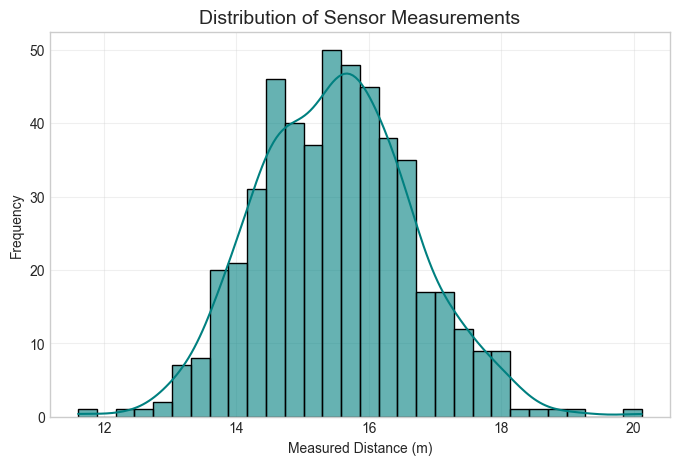

In [5]:
# Generate synthetic sensor measurements
true_distance_mu = 15.5   # True distance to target in meters
true_noise_sigma = 1.2    # Sensor noise standard deviation
n_measurements = 500

sensor_data = np.random.normal(loc=true_distance_mu, scale=true_noise_sigma, size=n_measurements)

# Let's introduce some deliberate "messiness" by rounding to simulate sensor precision
sensor_data = np.round(sensor_data, 2)

print(f'Generated {n_measurements} sensor readings.')
print(f'First 10 readings: {sensor_data[:10]}')

# Visualize the data
plt.figure(figsize=(8, 5))
sns.histplot(sensor_data, bins=30, kde=True, color='teal', alpha=0.6)
plt.title('Distribution of Sensor Measurements', fontsize=14)
plt.xlabel('Measured Distance (m)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

### Numerical Optimization for MLE

While the Gaussian MLE has a simple analytical solution (sample mean and sample variance), in many real-world machine learning models, we must use numerical optimization (like Gradient Descent or L-BFGS) to find the parameters.

Optimization libraries typically minimize functions. Therefore, we define the Negative Log-Likelihood (NLL) and minimize it. Minimizing NLL is mathematically identical to maximizing Log-Likelihood.

In [6]:
def gaussian_negative_log_likelihood(params, data):
    '''
    Computes the Negative Log-Likelihood for a Gaussian distribution.
    params: [mu, sigma]
    '''
    mu, sigma = params
    
    # Constraint: Sigma must be strictly positive
    if sigma <= 0:
        return np.inf
        
    # Use scipy.stats.norm.logpdf for numerical stability
    log_lik = np.sum(stats.norm.logpdf(data, loc=mu, scale=sigma))
    
    return -log_lik

# Initial guess for the optimizer [mu_guess, sigma_guess]
initial_guess = [0.0, 1.0]

# Parameter bounds: mu can be anything, sigma must be > 0
bounds = [(None, None), (1e-5, None)]

print('Starting numerical optimization...')
result = minimize(
    gaussian_negative_log_likelihood,
    x0=initial_guess,
    args=(sensor_data,),
    method='L-BFGS-B',
    bounds=bounds
)

opt_mu, opt_sigma = result.x
print('\nOptimization Complete:')
print(f'Success: {result.success}')
print(f'Message: {result.message}')
print(f'Estimated Mu (True={true_distance_mu}): {opt_mu:.4f}')
print(f'Estimated Sigma (True={true_noise_sigma}): {opt_sigma:.4f}')

Starting numerical optimization...

Optimization Complete:
Success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Estimated Mu (True=15.5): 15.5042
Estimated Sigma (True=1.2): 1.1726


### Visualizing the Fit

Let's overlay our Maximum Likelihood distribution on top of the empirical data to see how well our optimized parameters explain the reality.

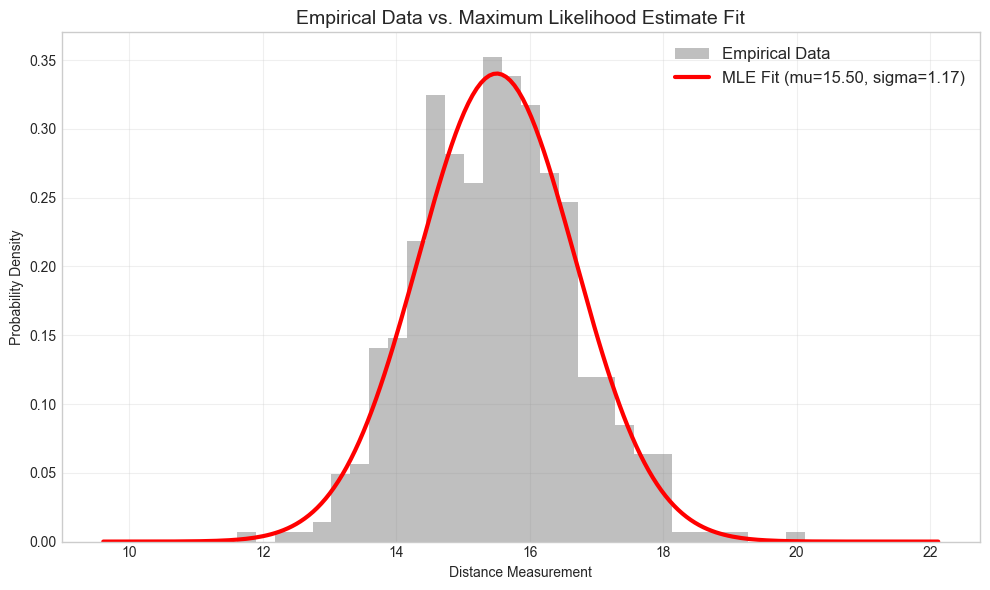

In [7]:
# Generate the theoretical PDF using our optimized MLE parameters
x_axis = np.linspace(min(sensor_data)-2, max(sensor_data)+2, 200)
mle_pdf = stats.norm.pdf(x_axis, loc=opt_mu, scale=opt_sigma)

plt.figure(figsize=(10, 6))
# Plot empirical data histogram as a density
plt.hist(sensor_data, bins=30, density=True, alpha=0.5, color='gray', label='Empirical Data')

# Plot the MLE fitted distribution
plt.plot(x_axis, mle_pdf, 'r-', lw=3, label=f'MLE Fit (mu={opt_mu:.2f}, sigma={opt_sigma:.2f})')

plt.title('Empirical Data vs. Maximum Likelihood Estimate Fit', fontsize=14)
plt.xlabel('Distance Measurement')
plt.ylabel('Probability Density')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Core Concept 3: Asymptotic Properties

Why is MLE the standard algorithm for estimation? Because of its behavior as sample size (n) goes to infinity. We will demonstrate two critical properties:

1. Consistency: The estimator converges perfectly to the true parameter.
2. Asymptotic Normality: The distribution of the estimator becomes Gaussian, allowing us to build confidence intervals.

In [8]:
# Simulating Consistency
sample_sizes = [10, 50, 100, 500, 1000, 5000]
n_simulations = 50
true_mean = 10.0

consistency_paths = np.zeros((n_simulations, len(sample_sizes)))

print('Running Monte Carlo simulation for Consistency...')
for i in range(n_simulations):
    # Generate massive dataset once per path
    full_data = np.random.normal(loc=true_mean, scale=2.0, size=max(sample_sizes))
    
    # Calculate MLE (sample mean) for increasing subsets of the data
    for j, n in enumerate(sample_sizes):
        consistency_paths[i, j] = np.mean(full_data[:n])

print('Simulation complete.')

Running Monte Carlo simulation for Consistency...
Simulation complete.


### Visualizing Consistency
Notice how as the sample size increases (moving right on the x-axis), the variance of our estimates shrinks dramatically, and all paths "lock onto" the true parameter line.

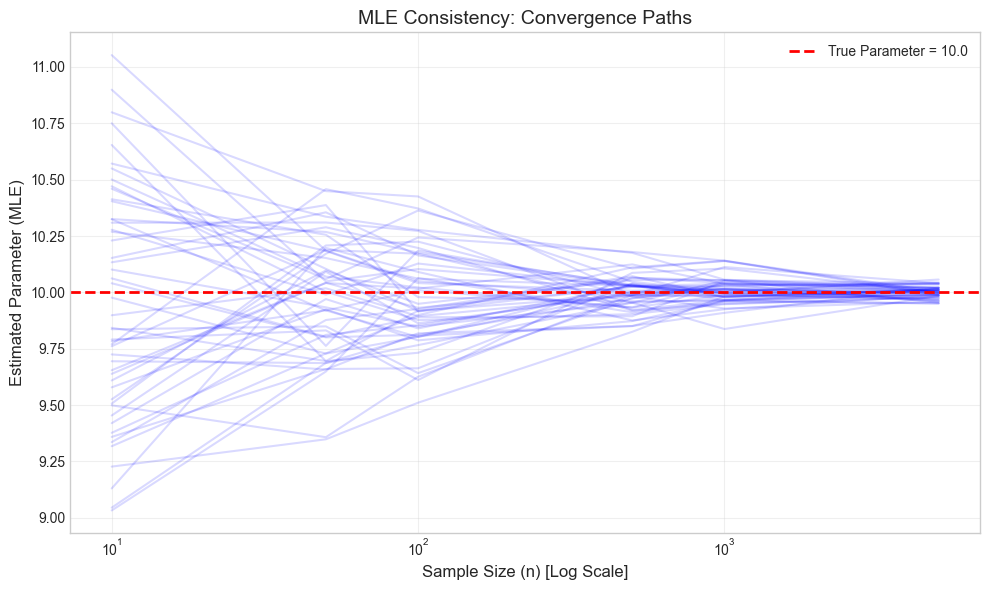

In [9]:
plt.figure(figsize=(10, 6))

# Plot every simulation path
for i in range(n_simulations):
    plt.plot(sample_sizes, consistency_paths[i], color='blue', alpha=0.15, lw=1.5)

# Plot the true parameter line
plt.axhline(true_mean, color='red', linestyle='--', lw=2, label=f'True Parameter = {true_mean}')

plt.xscale('log')
plt.title('MLE Consistency: Convergence Paths', fontsize=14)
plt.xlabel('Sample Size (n) [Log Scale]', fontsize=12)
plt.ylabel('Estimated Parameter (MLE)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Asymptotic Normality
If we repeat an experiment many times at a fixed sample size, the distribution of our MLE estimates will form a Gaussian curve centered on the true parameter. This proves that we can use standard z-scores for confidence intervals.

Running 2000 trials of sample size 50...


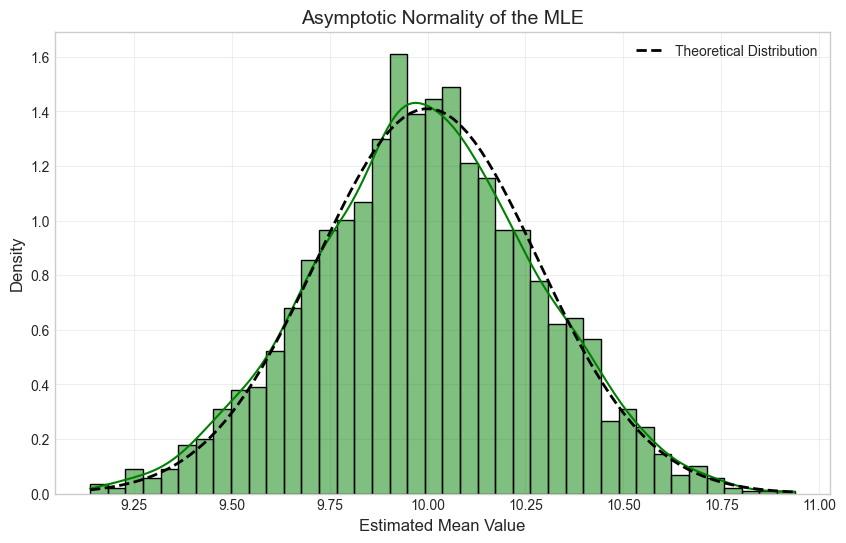

The distribution of the estimator is perfectly Gaussian.


In [10]:
# Simulating Asymptotic Normality
n_trials = 2000
fixed_n = 50
mle_estimates = np.zeros(n_trials)

print(f'Running {n_trials} trials of sample size {fixed_n}...')
for i in range(n_trials):
    data = np.random.normal(loc=true_mean, scale=2.0, size=fixed_n)
    mle_estimates[i] = np.mean(data)

plt.figure(figsize=(10, 6))
sns.histplot(mle_estimates, bins=40, kde=True, stat='density', color='green', alpha=0.5)

# Plot theoretical normal curve over it
theoretical_std = 2.0 / np.sqrt(fixed_n)
x_vals = np.linspace(min(mle_estimates), max(mle_estimates), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, true_mean, theoretical_std), 'k--', lw=2, label='Theoretical Distribution')

plt.title('Asymptotic Normality of the MLE', fontsize=14)
plt.xlabel('Estimated Mean Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print('The distribution of the estimator is perfectly Gaussian.')

## 6. Connection to Machine Learning: MSE is MLE

One of the most important proofs in ML is that minimizing Mean Squared Error (MSE) is mathematically identical to maximizing the Likelihood of the data under a Gaussian error assumption.

If y = f(x) + error, where error ~ Normal(0, sigma^2), then:
NLL = Constant + 1/(2*sigma^2) * Sum(y_i - f(x_i))^2

The summation term is exactly the Sum of Squared Errors. Let's prove they yield the same result using a simple linear regression.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generate synthetic regression data
X = np.random.uniform(0, 10, 100)
true_slope, true_intercept = 2.5, 4.0
noise = np.random.normal(0, 1.5, 100)
y = true_slope * X + true_intercept + noise

# Method 1: Ordinary Least Squares (Minimizing MSE directly)
lr = LinearRegression()
lr.fit(X.reshape(-1, 1), y)
ols_slope = lr.coef_[0]
ols_intercept = lr.intercept_

print('--- OLS (Minimizing Mean Squared Error) ---')
print(f'Slope: {ols_slope:.4f}, Intercept: {ols_intercept:.4f}')

--- OLS (Minimizing Mean Squared Error) ---
Slope: 2.5375, Intercept: 3.8308


Now we will formulate the exact same problem as a Gaussian Maximum Likelihood problem and optimize it using Scipy.

In [12]:
def regression_nll(params, X, y):
    '''Negative Log-Likelihood for Linear Regression under Gaussian noise'''
    slope, intercept, sigma = params
    if sigma <= 0:
        return np.inf
    
    # Predictions based on current parameters
    y_pred = slope * X + intercept
    
    # The likelihood of the actual y given the predicted mean and standard deviation
    nll = -np.sum(stats.norm.logpdf(y, loc=y_pred, scale=sigma))
    return nll

# Optimize the NLL
initial_guess_reg = [0.0, 0.0, 1.0]
bounds_reg = [(None, None), (None, None), (1e-5, None)]

res_reg = minimize(regression_nll, initial_guess_reg, args=(X, y), bounds=bounds_reg, method='L-BFGS-B')
mle_slope, mle_intercept, mle_sigma = res_reg.x

print('--- MLE (Maximizing Gaussian Likelihood) ---')
print(f'Slope: {mle_slope:.4f}, Intercept: {mle_intercept:.4f}')
print(f'\nDifference in Slope: {abs(ols_slope - mle_slope):.8f}')
print('Conclusion: MSE and Gaussian MLE are mathematically equivalent!')

--- MLE (Maximizing Gaussian Likelihood) ---
Slope: 2.5375, Intercept: 3.8308

Difference in Slope: 0.00000034
Conclusion: MSE and Gaussian MLE are mathematically equivalent!


## 7. Practice Exercise: MLE for Count Data

The Poisson distribution is used to model count data (e.g., number of customers arriving at a store in an hour). It has a single parameter, lambda, representing the expected rate of occurrences.

The PMF is: f(k | lambda) = (lambda^k * e^-lambda) / k!

Your task: Given the synthetic dataset below, find the Maximum Likelihood Estimate for lambda.

In [13]:
# Exercise Data Generation
true_lambda = 4.2
customer_arrivals = np.random.poisson(lam=true_lambda, size=200)

print('Sample of customer arrivals per hour:', customer_arrivals[:20])
print('Total hours recorded:', len(customer_arrivals))

Sample of customer arrivals per hour: [9 2 2 5 6 8 9 4 7 7 2 7 3 4 2 2 3 3 5 4]
Total hours recorded: 200


### Exercise Solution

If you write out the Log-Likelihood for the Poisson distribution and take the derivative with respect to lambda, you will find that the analytical MLE for lambda is simply the arithmetic mean of the observed counts.

lambda_hat = (1/n) * Sum(x_i)

Analytical MLE for lambda: 4.180


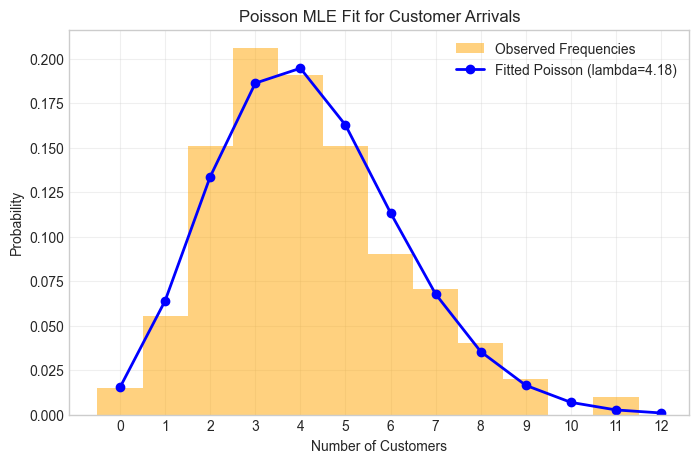

In [14]:
# Solution Implementation
lambda_hat = np.mean(customer_arrivals)

print(f'Analytical MLE for lambda: {lambda_hat:.3f}')

# Visualization of the fit
plt.figure(figsize=(8, 5))
bins = np.arange(0, max(customer_arrivals) + 1) - 0.5
plt.hist(customer_arrivals, bins=bins, density=True, alpha=0.5, color='orange', label='Observed Frequencies')

# Overlay the PMF curve
k_values = np.arange(0, max(customer_arrivals) + 1)
poisson_pmf = stats.poisson.pmf(k_values, mu=lambda_hat)
plt.plot(k_values, poisson_pmf, 'bo-', lw=2, label=f'Fitted Poisson (lambda={lambda_hat:.2f})')

plt.title('Poisson MLE Fit for Customer Arrivals')
plt.xlabel('Number of Customers')
plt.ylabel('Probability')
plt.xticks(k_values)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Visualization Gallery: The Likelihood Surface

To build better intuition, let's visualize the Negative Log-Likelihood surface in 3D for a Gaussian parameter estimation problem. The optimizer's job is to find the lowest point in this "valley".

Computing NLL surface for 3D plot...


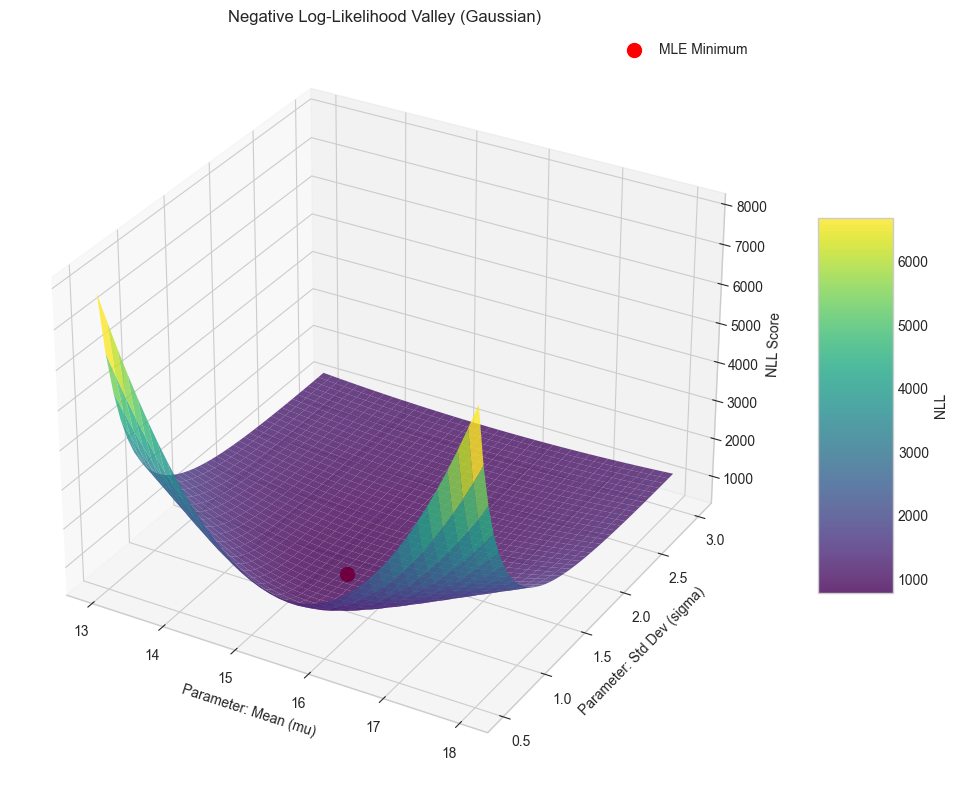

In [15]:
# 3D Surface Plot of Negative Log-Likelihood
mu_range = np.linspace(13.0, 18.0, 40)
sigma_range = np.linspace(0.5, 3.0, 40)
MU, SIGMA = np.meshgrid(mu_range, sigma_range)
Z = np.zeros_like(MU)

print('Computing NLL surface for 3D plot...')
for i in range(MU.shape[0]):
    for j in range(MU.shape[1]):
        Z[i, j] = gaussian_negative_log_likelihood([MU[i, j], SIGMA[i, j]], sensor_data)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(MU, SIGMA, Z, cmap='viridis', alpha=0.8, edgecolor='none')

# Mark the minimum point (the MLE)
min_z = gaussian_negative_log_likelihood([opt_mu, opt_sigma], sensor_data)
ax.scatter([opt_mu], [opt_sigma], [min_z], color='red', s=100, label='MLE Minimum', zorder=5)

ax.set_title('Negative Log-Likelihood Valley (Gaussian)')
ax.set_xlabel('Parameter: Mean (mu)')
ax.set_ylabel('Parameter: Std Dev (sigma)')
ax.set_zlabel('NLL Score')
ax.legend()

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='NLL')
plt.tight_layout()
plt.show()

## 9. Summary and Key Takeaways

### Conceptual Summary
- MLE evaluates parameters by assessing how probable the observed data is under those parameters.
- It shifts the epistemological framework: Data is fixed evidence; Parameters are hypotheses to be tuned.

### Mathematical Summary
- The natural logarithm converts multiplication into addition, preventing numeric underflow.
- The objective is mathematically formulated as: theta_hat = argmax L(theta|X).

### Common Mistakes
> Trap 1: Failing to use the log-likelihood in code, resulting in silent zeroing.
> Trap 2: Confusing probability (integrates to 1 over data) with likelihood (does not integrate to 1 over parameters).
> Trap 3: Not defining parameter bounds (like sigma > 0) when using numerical optimizers like L-BFGS-B.

### ML Integration
- Supervised learning relies completely on MLE. Mean Squared Error is the exact analytical equivalent of Gaussian MLE.
- Binary Cross Entropy is the exact equivalent of Bernoulli/Binomial MLE.